#### Transformation of Features

Q: Why transformation of Features are required?

A: Suppose you have x1 and x2 features and x1 = 20 and x2 = 200 so as you see, there are hugely the distance between x1 and x2, it means so hard to calculate what's the distance between x1 and x2 but if we transform these variables into some scale, the distance between x1 and x2 will be so close. That's the point.

Q: Do you have to use transformation or standardization in every algorithm?

A: Simply answer is no but you have to use it in some algorithm like linear regression or KNN or K Means.
    Deep Learning Techniques that you have to use standardization or scaling:
        1. ANN --> Global Minima, Gradient Descent
        2. CNN
        3. RNN

Types Of Transformation:
1. Normalization And Standardization
2. Scaling to Minimum And Maximum Values
3. Scaling To Median And Quantiles
4. Guassian Transformation
    Logarithmic Transformation
    Reciprocal Transformation
    Square Root Transformation
    Exponential Transformation
    Box Cox Transformation

In [1]:
#### Standardization
We try to bring all the variables or features to a similar scale
Z=(x-x_mean)/std

In [13]:
import pandas as pd

df = pd.read_csv(r"C:/Users/doguy/Downloads/titanic_train.csv", usecols = ["pclass","age","fare","survived"])

In [14]:
df.head()

,pclass,age,fare,survived
0,3,NaN,7.7333,1
1,3,38.0,8.6625,0
2,3,30.0,24.1500,0
3,2,54.0,23.0000,1
4,2,40.0,13.0000,0


In [16]:
df['age'].fillna(df.age.median(), inplace = True)

In [17]:
df.isnull().sum()

pclass      0
age         0
fare        1
survived    0
dtype: int64

In [21]:
#### Standarisation: We use the Strandarscaler from sklearn library

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#### Q: What's the difference of Fit vs Fit_Transform?

## A: fit, means to fit the pre-processor to the data being provided. 
#    This is where the pre-processor "learns" from the data.
#   transform means to transform the data (produce outputs) #
#    according to the fitted pre-processor; it is normally used on the test data, 
#    and unseen data in general (e.g. in new data that come after deploying a model).
#    fit_transform, means to do both 
#    - Fit the pre-processor to the data, then transform the data according to the fitted pre-processor. 
#    Calling fit_transform is a convenience to avoid needing to call fit and transform sequentially on the same input, 
#   but of course this is only applicable to the training data (calling again fit_transform in test or unseen data is
#                                                                unfortunately a common rookie mistake).

    
    
df_scaled = scaler.fit_transform(df)
pd.DataFrame(df_scaled)

,0,1,2,3
0,0.811420,-0.093041,-0.489610,1.309830
1,0.811420,0.676701,-0.472298,-0.763458
2,0.811420,0.060908,-0.183751,-0.763458
3,-0.381845,1.908287,-0.205177,1.309830
4,-0.381845,0.830649,-0.391486,-0.763458
...,...,...,...,...
845,-1.575110,1.985261,0.297858,-0.763458
846,-1.575110,2.216184,-0.080350,-0.763458
847,-0.381845,-0.400937,-0.149284,1.309830
848,0.811420,-2.017394,-0.377048,-0.763458


In [22]:
import matplotlib.pyplot as plt
%matplotlib inline

(array([ 35.,  14.,  16.,  27.,  81.,  96., 258.,  86.,  65.,  35.,  23.,
         31.,  28.,  20.,  15.,  12.,   3.,   2.,   2.,   1.]),
 array([-2.23548527, -1.92823024, -1.62097522, -1.31372019, -1.00646517,
        -0.69921014, -0.39195511, -0.08470009,  0.22255494,  0.52980996,
         0.83706499,  1.14432002,  1.45157504,  1.75883007,  2.06608509,
         2.37334012,  2.68059515,  2.98785017,  3.2951052 ,  3.60236022,
         3.90961525]),
 <BarContainer object of 20 artists>)

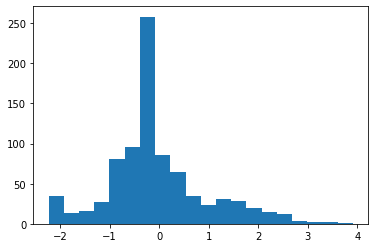

In [23]:
plt.hist(df_scaled[:,1], bins=20)

#### Min-Max Scaling

Aim: Min-Max Scaling scales the values between 0 to 1.

FORMULA

X_scaled = (feature - feature.min) / (feature.max - feature.min)

In [27]:
from sklearn.preprocessing import MinMaxScaler
min_max = MinMaxScaler()
df_minmax = pd.DataFrame(min_max.fit_transform(df),columns=df.columns)

In [29]:
df_minmax

,pclass,age,fare,survived
0,1.0,0.348643,0.015094,1.0
1,1.0,0.473904,0.016908,0.0
2,1.0,0.373695,0.047138,0.0
3,0.5,0.674321,0.044893,1.0
4,0.5,0.498956,0.025374,0.0
...,...,...,...,...
845,0.0,0.686847,0.097594,0.0
846,0.0,0.724426,0.057971,0.0
847,0.5,0.298538,0.050749,1.0
848,1.0,0.035490,0.026887,0.0


(array([206.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 166.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 478.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

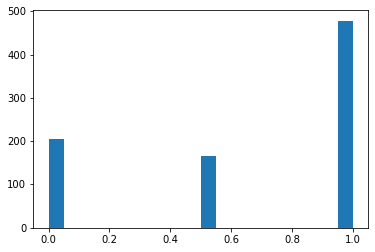

In [30]:
plt.hist(df_minmax.pclass,bins = 20)

(array([543., 144.,  71.,  34.,  13.,  14.,   3.,   0.,  14.,   1.,   9.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

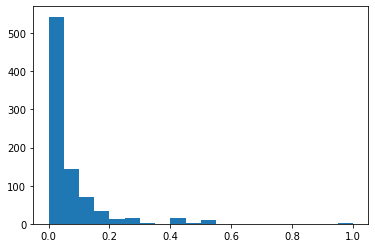

In [31]:
plt.hist(df_minmax.fare,bins = 20)

##### Robust Scaler

It is used to scale the features to median and quantiles

Q: What is interquantile difference
    
A: Scaling using median and quantiles consists of substracting the median to all the observations and then dividing 
    by the interquantile difference. The interquantile difference is the difference between the 75th and 25th quantile
    
    For example: 0,1,2,3,4,5,6,7,8,9,10
        What is the interquantile of 2 ?
            it is 20 percentile because %20 of all values in this group is less than 2

In [37]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df_robust_scaler = pd.DataFrame(scaler.fit_transform(df),columns=df.columns)

df.head()

,pclass,age,fare,survived
0,3,28.0,7.7333,1
1,3,38.0,8.6625,0
2,3,30.0,24.1500,0
3,2,54.0,23.0000,1
4,2,40.0,13.0000,0


(array([543., 144.,  71.,  34.,  13.,  14.,   3.,   0.,  14.,   1.,   9.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.]),
 array([-0.61063789,  0.49809818,  1.60683426,  2.71557033,  3.8243064 ,
         4.93304248,  6.04177855,  7.15051463,  8.2592507 ,  9.36798677,
        10.47672285, 11.58545892, 12.69419499, 13.80293107, 14.91166714,
        16.02040322, 17.12913929, 18.23787536, 19.34661144, 20.45534751,
        21.56408359]),
 <BarContainer object of 20 artists>)

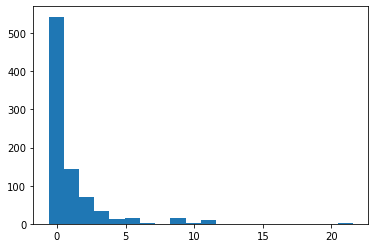

In [38]:
plt.hist(df_robust_scaler.fare,bins = 20)

Guassian Transformation
    Logarithmic Transformation
    Reciprocal Transformation
    Square Root Transformation
    Exponential Transformation
    Box Cox Transformation
    
Aim: Suppouse your distrubation is not normal then we can apply some mathematical equation like logarithmic transformation.
Some machine learning algorithms like linear and logistic assume that the features are normally distributed.
    -Accuracy
    -Performance

In [40]:
df = pd.read_csv(r"C:/Users/doguy/Downloads/titanic_train.csv", usecols = ["age","fare","survived"])
df.head()

,age,fare,survived
0,NaN,7.7333,1
1,38.0,8.6625,0
2,30.0,24.1500,0
3,54.0,23.0000,1
4,40.0,13.0000,0


In [43]:
### fillnan

df.age = df.age.fillna(df.age.median())
df.isnull().sum()

age         0
fare        1
survived    0
dtype: int64

In [51]:
# If you want to check whether feature is guassion or normal distrubated
#### Q-Q plot

import scipy.stats as stat
import pylab

def plot_data(df,feature):
    plt.figure(figsize=(20,60))
    plt.subplot(1,2,1)
    df[feature].hist()
    plt.subplot(1,2,2)
    stat.probplot(df[feature],dist='norm',plot=pylab)

    

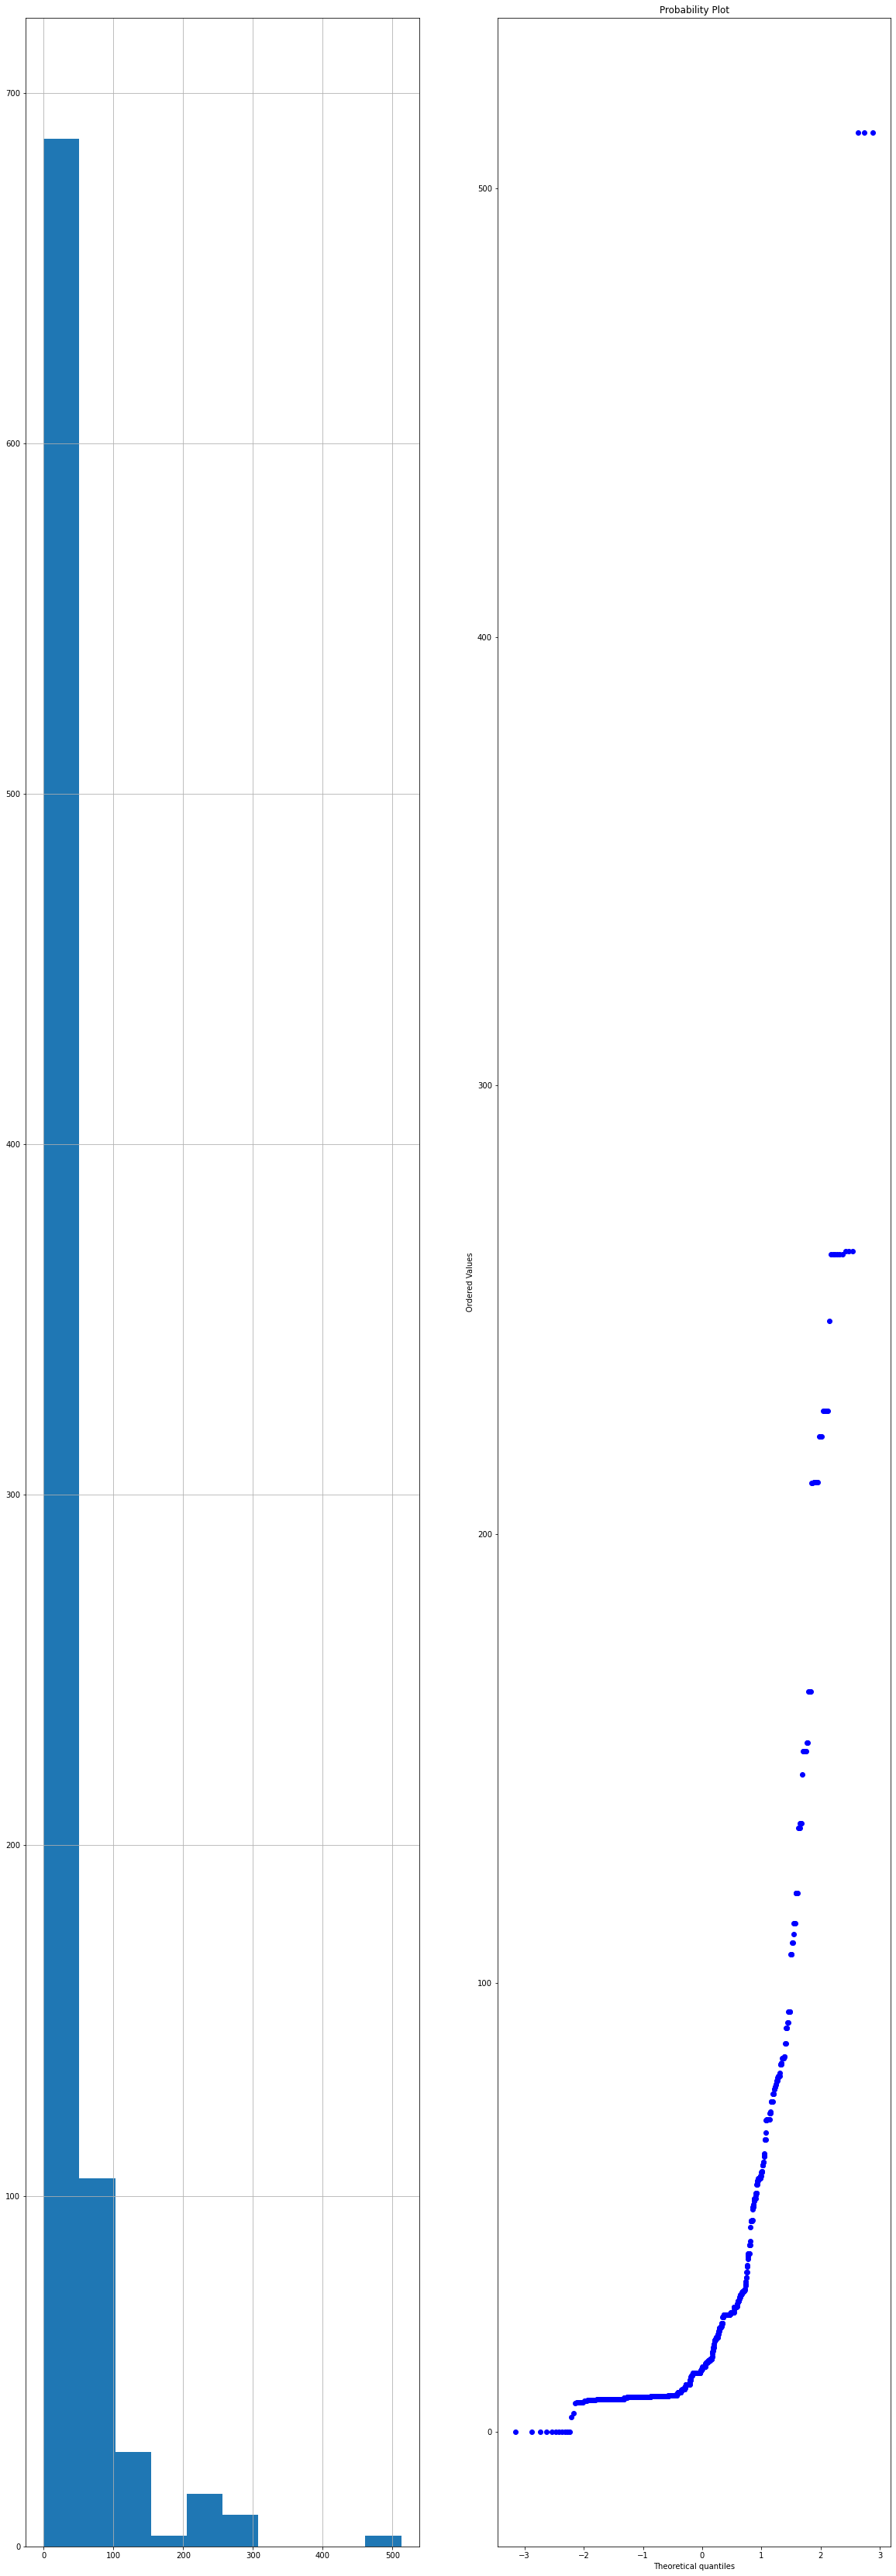

In [52]:
plot_data(df,'fare')

#### Logarithmic Transformation


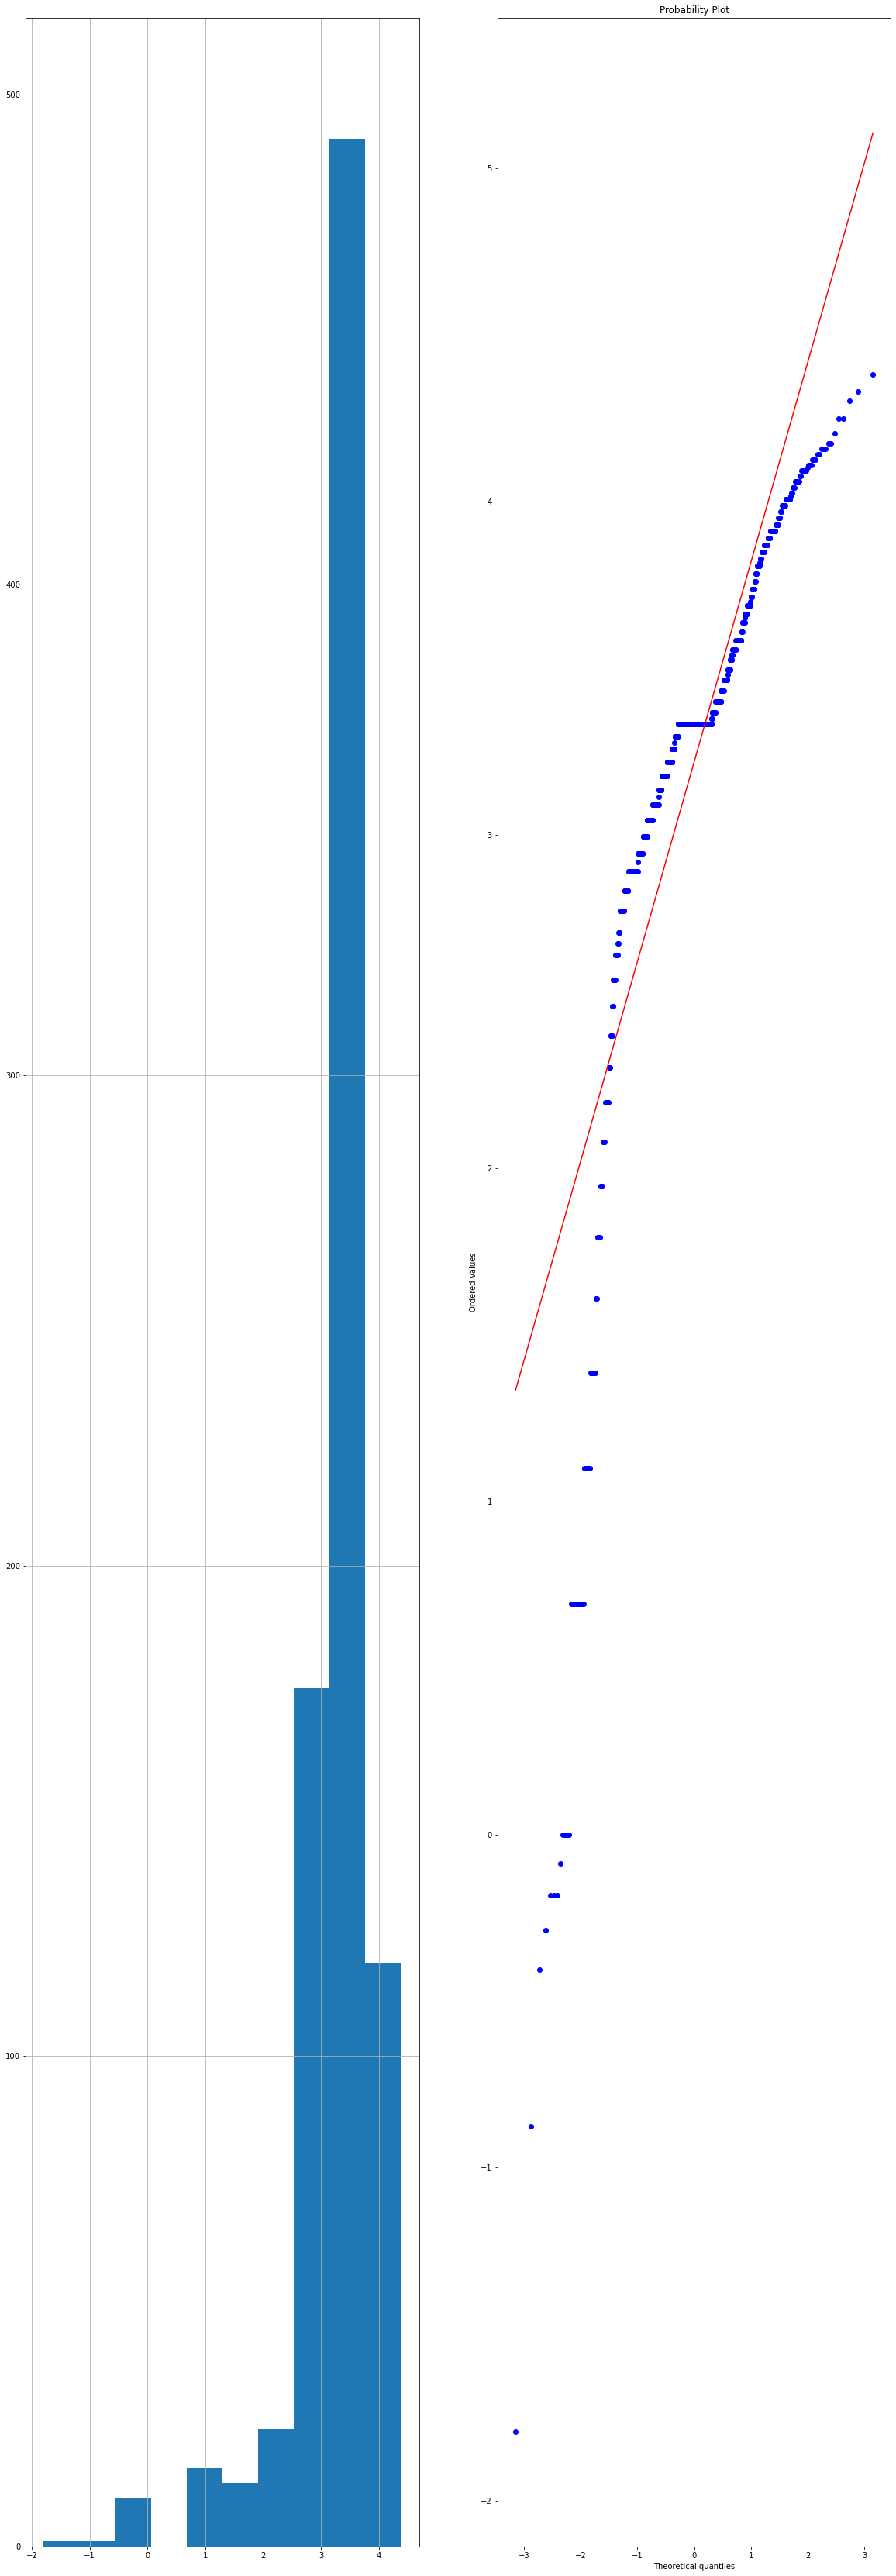

In [53]:
import numpy as np
df["Age_log"] = np.log(df['age'])
plot_data(df,'Age_log')

In [ ]:
# Logarithmic transformation works well when the distrubation is right skewed or left skewed